In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [11]:
img = cv2.imread('asd.jpg')

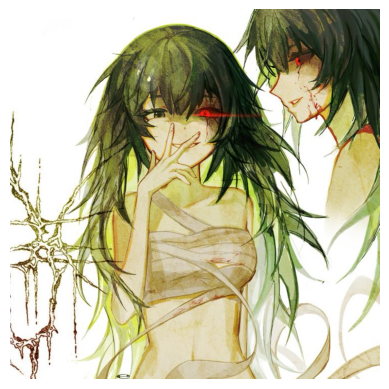

In [13]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

# Метод Shi-Tomasi (нахождение ключевых точек)

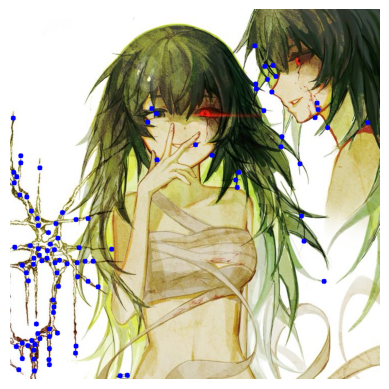

In [22]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
# maxCorners - задает число точек
# qualityLevel - минимальное значение отклика
# minDistace - минимальное расстояние между найденными точками

img_corners = img.copy()

if corners is not None:
    corners = np.int64(corners)
    for i in corners:
        x, y = i.ravel()
        cv2.circle(img_corners, (x, y), 5, (0, 0, 255), -1)

plt.imshow(img_corners)
plt.axis('off')
plt.show()

# Дескрипторы признаков

## ORB - дескриптор

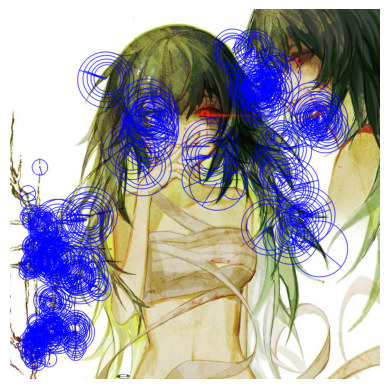

In [25]:
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img, None)

img_kp = cv2.drawKeypoints(img, kp1, None, color=(0, 0, 255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
# Флаг DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS показывает размер и ориентацию точек

plt.imshow(img_kp)
plt.axis('off')
plt.show()

# Применение сопоставления (ORB + BruteForce)

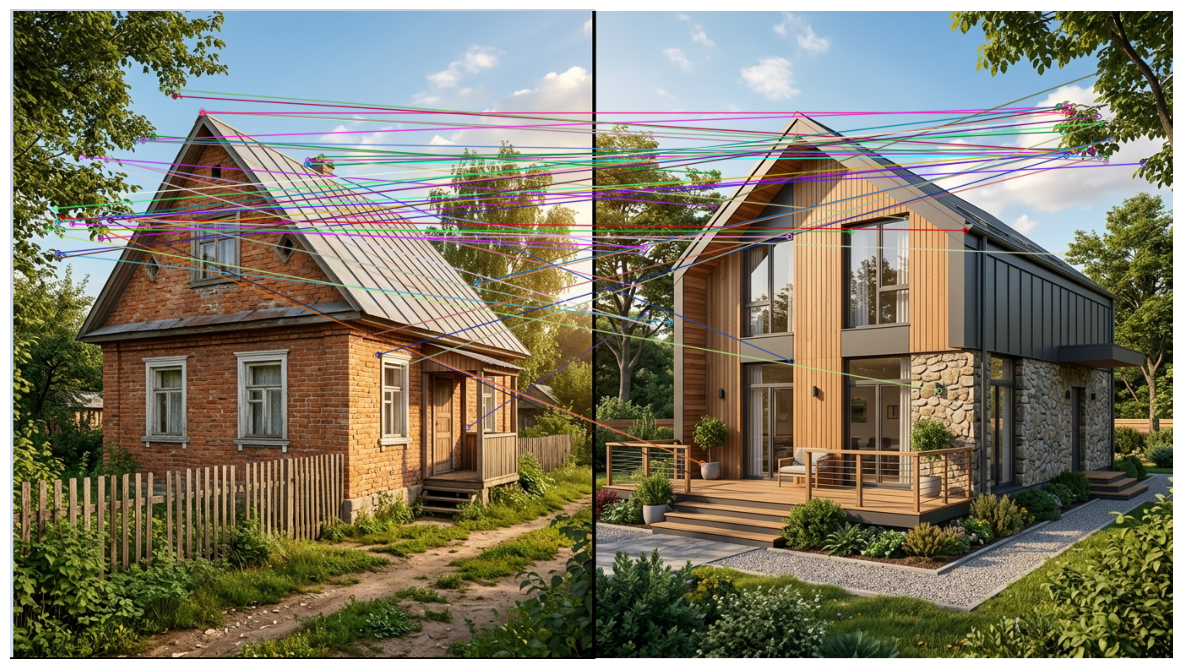

In [38]:
import cv2
import matplotlib.pyplot as plt

# 1. Загружаем два изображения
img1 = cv2.imread('dom1.png')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # Переводим в RGB для Matplotlib

# Замените 'img2.png' на имя вашего второго файла
img2 = cv2.imread('dom2.png') 
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# 2. Инициализируем ORB
orb = cv2.ORB_create(nfeatures=500)

# 3. Находим ключевые точки и дескрипторы для ОБОИХ изображений
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# 4. Создаем Brute-Force Matcher с метрикой HAMMING (идеально для ORB)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# 5. Находим совпадения
matches = bf.match(des1, des2)

# 6. Сортируем совпадения по расстоянию (лучшие — в начале списка)
matches = sorted(matches, key=lambda x: x.distance)

# 7. Отрисовываем, например, топ-50 лучших совпадений
matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# 8. Выводим результат
plt.figure(figsize=(15, 10))
plt.imshow(matched_img)
plt.axis('off')
plt.show()
